In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
sns.set_style("whitegrid")

In [ ]:
pd.set_option('display.max_columns', 50)

In [3]:
df = pd.read_csv("merged_streaming_data.csv")
df.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [4]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'date', 'forumng',
       'homepage', 'oucontent', 'subpage', 'url', 'resource', 'glossary',
       'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 'sharedsubpage',
       'questionnaire', 'page', 'externalquiz', 'ouwiki', 'dualpane',
       'repeatactivity', 'folder', 'htmlactivity', 'id_assessment',
       'is_banked', 'score', 'assessment_type', 'due_date', 'weight',
       'module_presentation_length', 'gender', 'region', 'highest_education',
       'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits',
       'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')

In [5]:
course_student_cols = df.columns[:3].tolist() + df.columns[30:].tolist()
course_student_vle_cols = df.columns[:24].tolist() + df.columns[30:].tolist()
course_student_assessment_cols = df.columns[:4].tolist() + df.columns[24:].tolist()

In [6]:
# e.g., if I'm only interested in learning about the courses 
df_meta = df[course_student_cols].drop_duplicates()
df_meta.head()

,id_student,code_module,code_presentation,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
159,8462,DDD,2013J,261,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,-137.0,119.0
215,8462,DDD,2014J,262,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn,-38.0,18.0
220,11391,AAA,2013J,268,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN
263,23629,BBB,2013B,240,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,Fail,-47.0,NaN


In [7]:
df_meta.groupby(["code_module", "code_presentation"])["module_presentation_length"].unique()

code_module  code_presentation
AAA          2013J                [268]
             2014J                [269]
BBB          2013B                [240]
             2013J                [268]
             2014B                [234]
             2014J                [262]
CCC          2014B                [241]
             2014J                [269]
DDD          2013B                [240]
             2013J                [261]
             2014B                [241]
             2014J                [262]
EEE          2013J                [268]
             2014B                [241]
             2014J                [269]
FFF          2013B                [240]
             2013J                [268]
             2014B                [241]
             2014J                [269]
GGG          2013J                [261]
             2014B                [241]
             2014J                [269]
Name: module_presentation_length, dtype: object

In [8]:
df_lengths = (
    df_meta
    .groupby(["code_module", "code_presentation"], as_index=False)
    ["module_presentation_length"]
    .first()
)

df_lengths

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013B,240
3,BBB,2013J,268
4,BBB,2014B,234
5,BBB,2014J,262
6,CCC,2014B,241
7,CCC,2014J,269
8,DDD,2013B,240
9,DDD,2013J,261


In [9]:
df_students = (
    df_meta
    .groupby(["code_module", "code_presentation"], as_index=False)
    ["id_student"]
    .nunique()
    .rename(columns={"id_student": "num_unique_students"})
)

df_students

,code_module,code_presentation,num_unique_students
0,AAA,2013J,378
1,AAA,2014J,357
2,BBB,2013B,1538
3,BBB,2013J,1883
4,BBB,2014B,1299
5,BBB,2014J,1925
6,CCC,2014B,1681
7,CCC,2014J,2305
8,DDD,2013B,1217
9,DDD,2013J,1772


In [10]:
df_course_students = df_lengths.merge(df_students, on=["code_module", "code_presentation"], how="left")

df_course_students

,code_module,code_presentation,module_presentation_length,num_unique_students
0,AAA,2013J,268,378
1,AAA,2014J,269,357
2,BBB,2013B,240,1538
3,BBB,2013J,268,1883
4,BBB,2014B,234,1299
5,BBB,2014J,262,1925
6,CCC,2014B,241,1681
7,CCC,2014J,269,2305
8,DDD,2013B,240,1217
9,DDD,2013J,261,1772


In [11]:
df_firsttime = (
    df_meta[df_meta["num_of_prev_attempts"] == 0]
    .groupby(["code_module", "code_presentation"], as_index=False)
    ["id_student"]
    .nunique()
    .rename(columns={"id_student": "num_unique_students_firsttime"})
)

df_course_students = df_course_students.merge(df_firsttime, on=["code_module", "code_presentation"], how="left")

df_course_students

,code_module,code_presentation,module_presentation_length,num_unique_students,num_unique_students_firsttime
0,AAA,2013J,268,378,378
1,AAA,2014J,269,357,318
2,BBB,2013B,240,1538,1240
3,BBB,2013J,268,1883,1602
4,BBB,2014B,234,1299,1085
5,BBB,2014J,262,1925,1705
6,CCC,2014B,241,1681,1681
7,CCC,2014J,269,2305,2087
8,DDD,2013B,240,1217,962
9,DDD,2013J,261,1772,1499


In [12]:
df_meta_assessments = df[course_student_assessment_cols].dropna(subset=["id_assessment"])
df_meta_assessments.head()

,id_student,code_module,code_presentation,date,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
21,6516,AAA,2014J,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
40,6516,AAA,2014J,51.0,1759.0,0.0,48.0,TMA,54.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
73,6516,AAA,2014J,116.0,1760.0,0.0,63.0,TMA,117.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
103,6516,AAA,2014J,164.0,1761.0,0.0,61.0,TMA,166.0,20.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
136,6516,AAA,2014J,210.0,1762.0,0.0,77.0,TMA,215.0,30.0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [15]:
df_num_assessment = (
    df_meta_assessments
    .groupby(["code_module", "code_presentation","assessment_type"], as_index=False)
    .agg(
        num_unique_assessments=("id_assessment", "nunique")
    )
)

df_num_assessment

,code_module,code_presentation,assessment_type,num_unique_assessments
0,AAA,2013J,TMA,5
1,AAA,2014J,TMA,5
2,BBB,2013B,CMA,5
3,BBB,2013B,TMA,6
4,BBB,2013J,CMA,5
5,BBB,2013J,TMA,6
6,BBB,2014B,CMA,5
7,BBB,2014B,TMA,6
8,BBB,2014J,TMA,5
9,CCC,2014B,CMA,4


In [17]:
df_wide = (
    df_num_assessment
    .pivot_table(
        index=["code_module", "code_presentation"],
        columns="assessment_type",
        values="num_unique_assessments",
        fill_value=0  # fills missing combinations with 0
    )
    .reset_index()
)

df_wide.columns.name = None  # remove the pivot column name

df_wide

,code_module,code_presentation,CMA,Exam,TMA
0,AAA,2013J,0.0,0.0,5.0
1,AAA,2014J,0.0,0.0,5.0
2,BBB,2013B,5.0,0.0,6.0
3,BBB,2013J,5.0,0.0,6.0
4,BBB,2014B,5.0,0.0,6.0
5,BBB,2014J,0.0,0.0,5.0
6,CCC,2014B,4.0,1.0,4.0
7,CCC,2014J,4.0,1.0,4.0
8,DDD,2013B,7.0,1.0,6.0
9,DDD,2013J,0.0,1.0,6.0


In [18]:
df_vle = df[course_student_vle_cols].drop_duplicates()
df_vle.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN


In [51]:
df_meta_assessments.columns

Index(['id_student', 'code_module', 'code_presentation', 'date',
       'id_assessment', 'is_banked', 'score', 'assessment_type', 'due_date',
       'weight', 'module_presentation_length', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration'],
      dtype='object')

In [55]:
df_assessment_duedates = df_meta_assessments[
    ["code_module", "code_presentation", "id_assessment", "assessment_type", "due_date", "weight"]
].drop_duplicates()

df_assessment_duedates.head()

,code_module,code_presentation,id_assessment,assessment_type,due_date,weight
21,AAA,2014J,1758.0,TMA,19.0,10.0
40,AAA,2014J,1759.0,TMA,54.0,20.0
73,AAA,2014J,1760.0,TMA,117.0,20.0
103,AAA,2014J,1761.0,TMA,166.0,20.0
136,AAA,2014J,1762.0,TMA,215.0,30.0


In [19]:
vle_columns = [
    'forumng', 'homepage', 'oucontent', 'subpage', 'url', 'resource', 
    'glossary', 'dataplus', 'oucollaborate', 'quiz', 'ouelluminate', 
    'sharedsubpage', 'questionnaire', 'page', 'externalquiz', 'ouwiki', 
    'dualpane', 'repeatactivity', 'folder', 'htmlactivity'
]

df_vle["total_vle_interactions"] = df_vle[vle_columns].sum(axis=1)

df_vle.head()

,id_student,code_module,code_presentation,date,forumng,homepage,oucontent,subpage,url,resource,glossary,dataplus,oucollaborate,quiz,ouelluminate,sharedsubpage,questionnaire,page,externalquiz,ouwiki,dualpane,repeatactivity,folder,htmlactivity,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,total_vle_interactions
0,6516,AAA,2014J,-23.0,0,3,23,2,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,28.0
1,6516,AAA,2014J,-22.0,33,13,34,0,0,2,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,82.0
2,6516,AAA,2014J,-20.0,13,12,8,1,0,7,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,41.0
3,6516,AAA,2014J,-17.0,0,2,0,3,2,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,7.0
4,6516,AAA,2014J,-12.0,1,1,0,0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,269,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,2.0


In [83]:
daily_total_vle = df_vle.groupby(["code_module","code_presentation","date"], as_index=False).agg(total_vle=("total_vle_interactions", "sum"))

daily_total_vle.head()

,code_module,code_presentation,date,total_vle
0,AAA,2013J,-10.0,11952.0
1,AAA,2013J,-9.0,5649.0
2,AAA,2013J,-8.0,3499.0
3,AAA,2013J,-7.0,3610.0
4,AAA,2013J,-6.0,4154.0


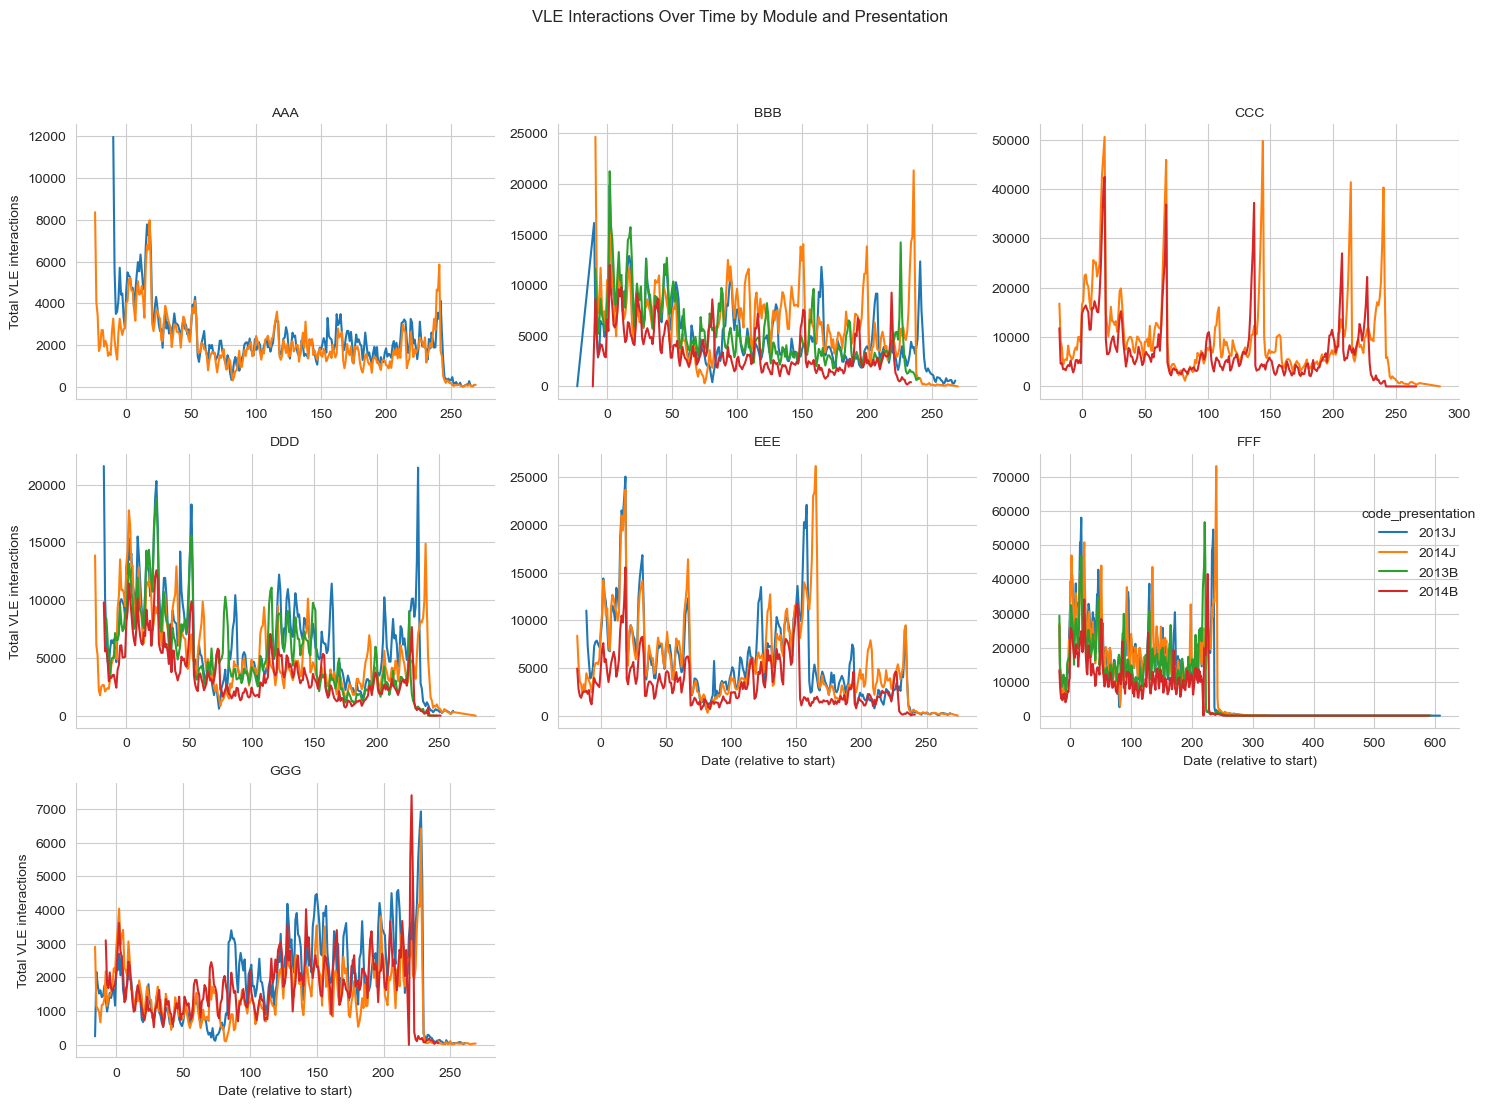

In [31]:
g = sns.relplot(
    data=daily_total_vle,
    x="date",
    y="total_vle",
    hue="code_presentation",   # color by presentation
    kind="line",
    col="code_module",         # one panel per module
    col_wrap=3,                # number of columns before wrapping
    height=3.5,                # height of each facet
    aspect=1.3,                # width-to-height ratio
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Total VLE interactions")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
daily_avg_vle = df_vle.groupby(["code_module","code_presentation","date"], as_index=False).agg(avg_vle=("total_vle_interactions", "mean"), num_active_students=("id_student","nunique"))

daily_avg_vle = daily_avg_vle.merge(df_course_students[["code_module","code_presentation","num_unique_students","num_unique_students_firsttime"]], on=["code_module", "code_presentation"], how="left")

daily_avg_vle["percent_active_students"] = daily_avg_vle["num_active_students"]/daily_avg_vle["num_unique_students"]*100

daily_avg_vle.head()

# NB: this includes all students, but I think eventually we only want to include students that have 'num_of_prev_attempts'=0

,code_module,code_presentation,date,avg_vle,num_active_students,num_unique_students,num_unique_students_firsttime,percent_active_students
0,AAA,2013J,-10.0,50.008368,239,378,378,63.227513
1,AAA,2013J,-9.0,27.827586,203,378,378,53.703704
2,AAA,2013J,-8.0,25.727941,136,378,378,35.978836
3,AAA,2013J,-7.0,28.650794,126,378,378,33.333333
4,AAA,2013J,-6.0,30.101449,138,378,378,36.507937


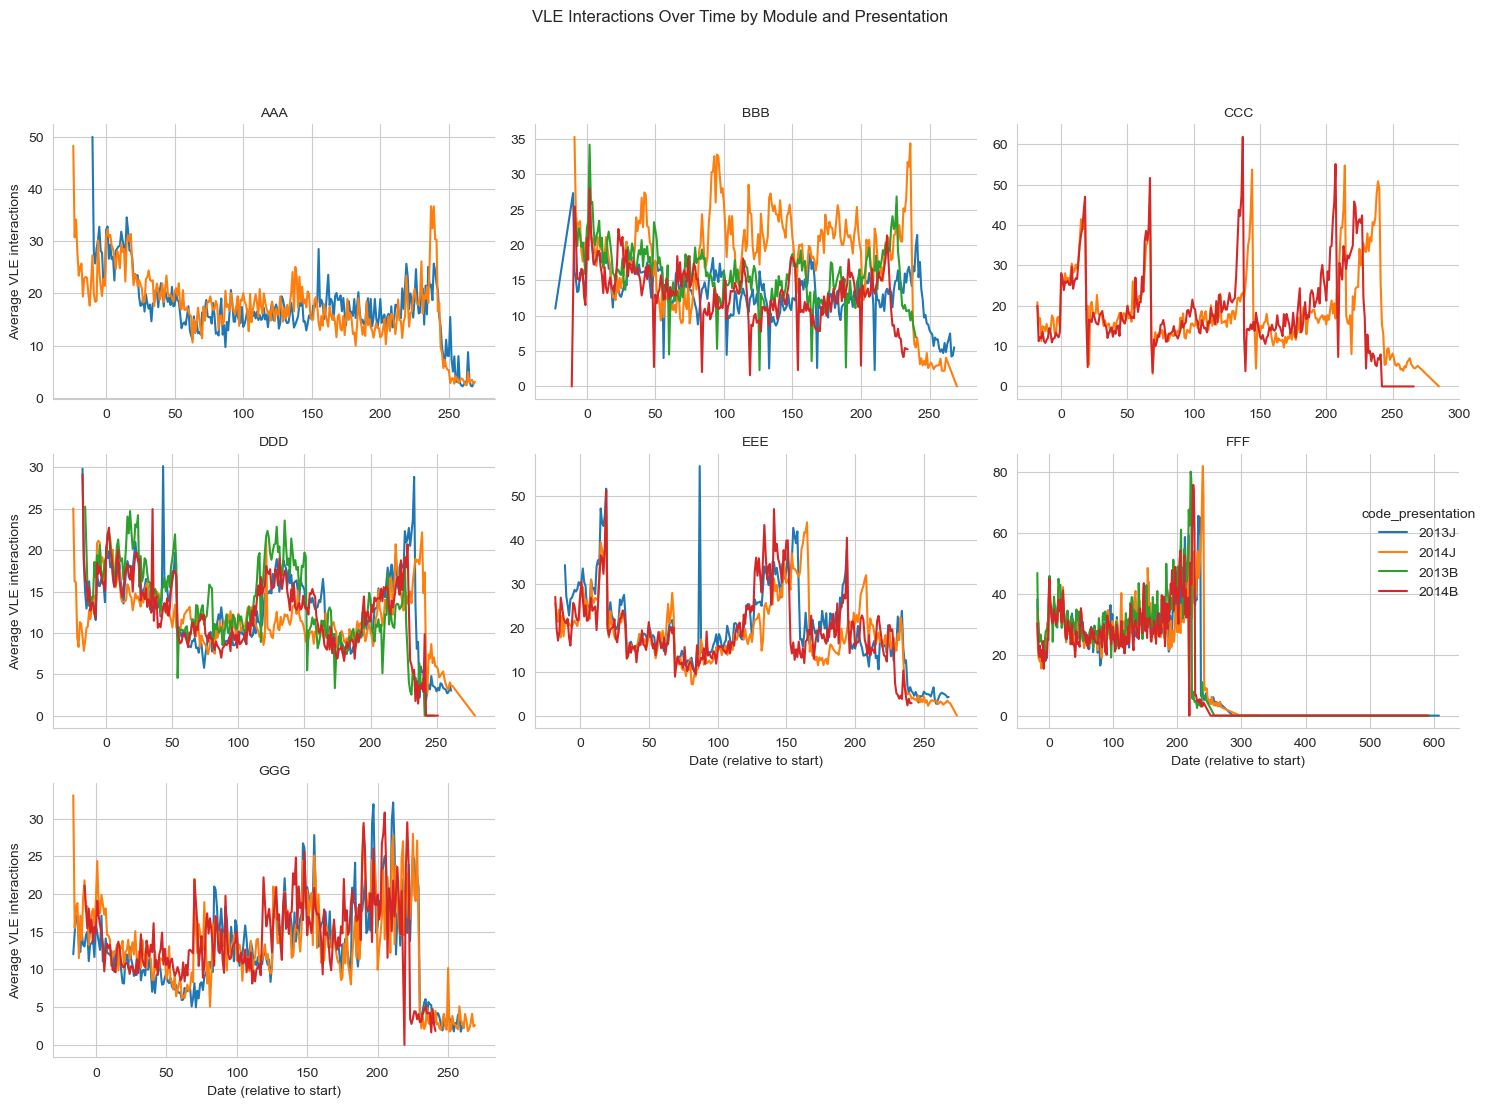

In [40]:
g = sns.relplot(
    data=daily_avg_vle,
    x="date",
    y="avg_vle",
    hue="code_presentation",   # color by presentation
    kind="line",
    col="code_module",         # one panel per module
    col_wrap=3,                # number of columns before wrapping
    height=3.5,                # height of each facet
    aspect=1.3,                # width-to-height ratio
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Average VLE interactions")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()

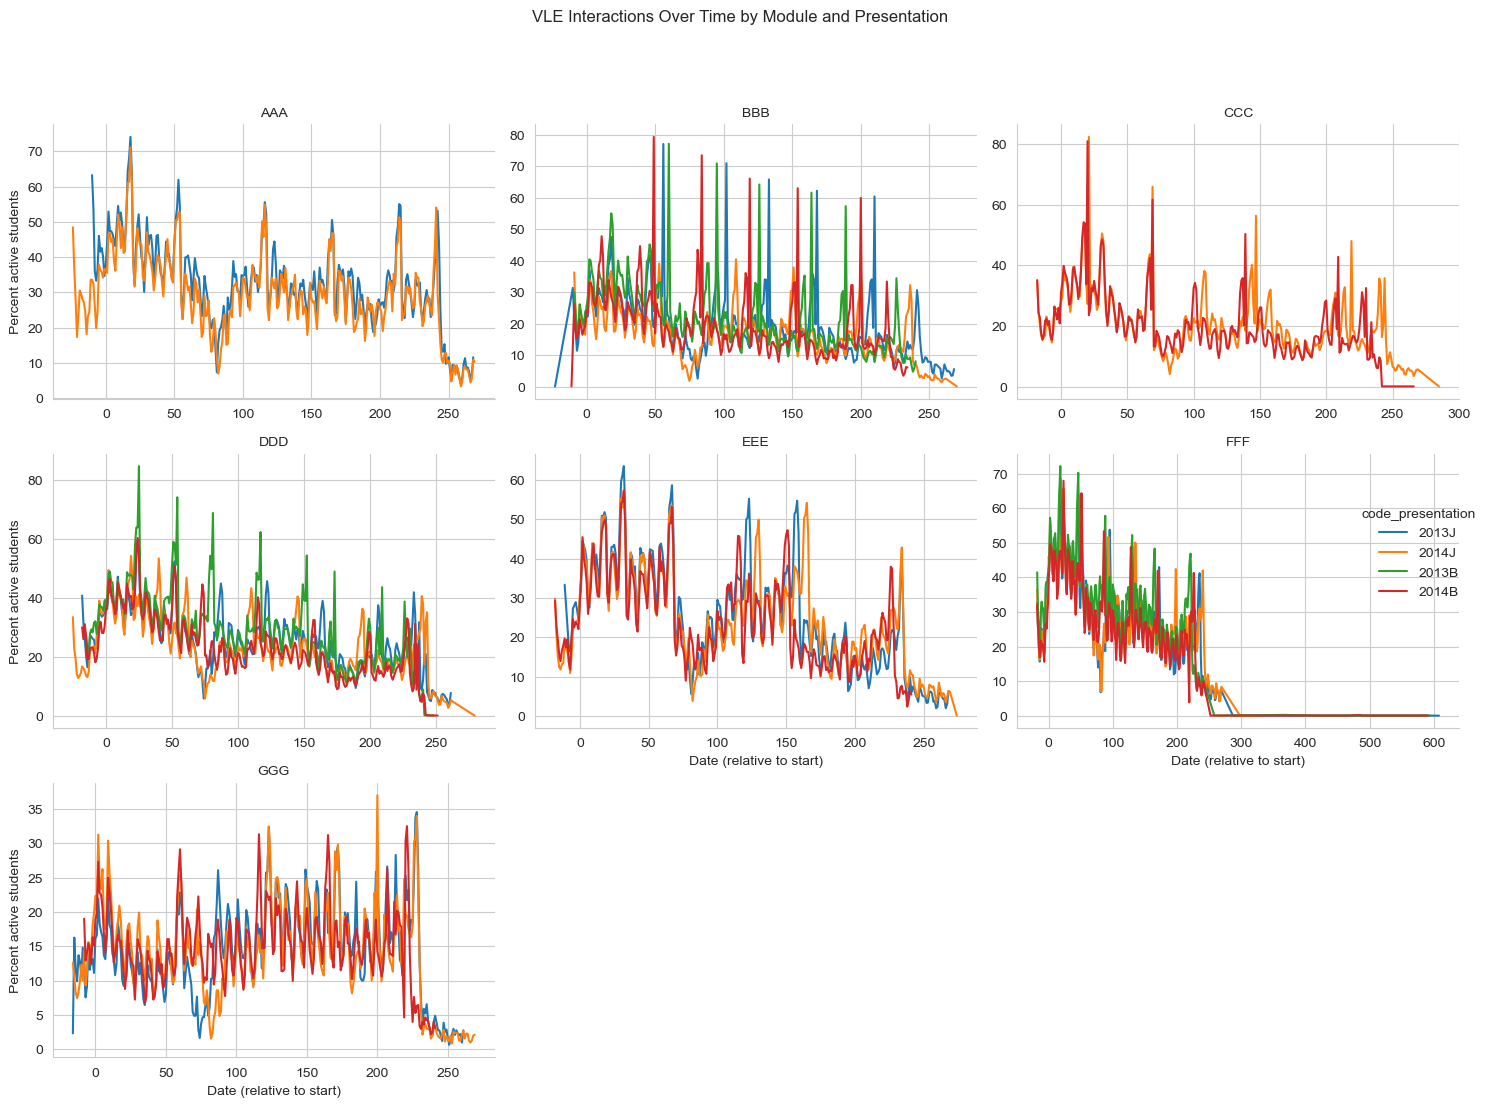

In [39]:
g = sns.relplot(
    data=daily_avg_vle,
    x="date",
    y="percent_active_students",
    hue="code_presentation",   # color by presentation
    kind="line",
    col="code_module",         # one panel per module
    col_wrap=3,                # number of columns before wrapping
    height=3.5,                # height of each facet
    aspect=1.3,                # width-to-height ratio
    facet_kws={"sharey": False, "sharex": False}
)

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Percent active students")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)
plt.tight_layout()
plt.show()

Check if peaks in activity relate to assessments 

In [62]:
# For each module/presentation, find dates where activity spikes
daily_avg_vle['rank_within_presentation'] = (
    daily_avg_vle
    .groupby(['code_module', 'code_presentation'])['percent_active_students']
    .rank(method='dense', ascending=False)
)

# Top N peaks per group (e.g., top 5)
peaks = (
    daily_avg_vle
    .query("rank_within_presentation <= 5")
    .sort_values(['code_module', 'code_presentation', 'date'])
)

print(peaks)

     code_module code_presentation   date    avg_vle  num_active_students  \
0            AAA             2013J  -10.0  50.008368                  239   
26           AAA             2013J   16.0  31.991770                  243   
27           AAA             2013J   17.0  28.217899                  257   
28           AAA             2013J   18.0  28.146429                  280   
29           AAA             2013J   19.0  26.933884                  242   
...          ...               ...    ...        ...                  ...   
5767         GGG             2014J    2.0  18.541284                  218   
5888         GGG             2014J  123.0   9.964602                  226   
5965         GGG             2014J  200.0   9.949612                  258   
5992         GGG             2014J  227.0  19.046512                  215   
5993         GGG             2014J  228.0  27.084388                  237   

      num_unique_students  num_unique_students_firsttime  \
0              

In [64]:
peaks_with_assessment = (
    peaks
    .merge(df_assessment_duedates, on=["code_module", "code_presentation"], how="left")
    .assign(days_to_due=lambda x: x['date'] - x['due_date'])
)

peaks_with_assessment

,code_module,code_presentation,date,avg_vle,num_active_students,num_unique_students,num_unique_students_firsttime,percent_active_students,rank_within_presentation,id_assessment,assessment_type,due_date,weight,days_to_due
0,AAA,2013J,-10.0,50.008368,239,378,378,63.227513,5.0,1752.0,TMA,19.0,10.0,-29.0
1,AAA,2013J,-10.0,50.008368,239,378,378,63.227513,5.0,1753.0,TMA,54.0,20.0,-64.0
2,AAA,2013J,-10.0,50.008368,239,378,378,63.227513,5.0,1754.0,TMA,117.0,20.0,-127.0
3,AAA,2013J,-10.0,50.008368,239,378,378,63.227513,5.0,1755.0,TMA,166.0,20.0,-176.0
4,AAA,2013J,-10.0,50.008368,239,378,378,63.227513,5.0,1756.0,TMA,215.0,30.0,-225.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,GGG,2014J,228.0,27.084388,237,698,670,33.954155,2.0,37437.0,TMA,173.0,0.0,55.0
959,GGG,2014J,228.0,27.084388,237,698,670,33.954155,2.0,37440.0,CMA,229.0,0.0,-1.0
960,GGG,2014J,228.0,27.084388,237,698,670,33.954155,2.0,37441.0,CMA,229.0,0.0,-1.0
961,GGG,2014J,228.0,27.084388,237,698,670,33.954155,2.0,37443.0,CMA,229.0,0.0,-1.0


In [60]:
# Check if peaks happen within ±2 days of due dates
near_due = peaks_with_assessment.query("days_to_due.abs() <= 2")
print(near_due[['code_module', 'code_presentation', 'date', 'due_date', 'days_to_due',"assessment_type","weight"]])

    code_module code_presentation   date  due_date  days_to_due  \
5           AAA             2013J   17.0      19.0         -2.0   
10          AAA             2013J   18.0      19.0         -1.0   
20          AAA             2014J   17.0      19.0         -2.0   
25          AAA             2014J   18.0      19.0         -1.0   
30          AAA             2014J   19.0      19.0          0.0   
..          ...               ...    ...       ...          ...   
563         GGG             2014J  228.0     229.0         -1.0   
565         GGG             2014J  228.0     229.0         -1.0   
566         GGG             2014J  228.0     229.0         -1.0   
567         GGG             2014J  228.0     229.0         -1.0   
568         GGG             2014J  228.0     229.0         -1.0   

    assessment_type  weight  
5               TMA    10.0  
10              TMA    10.0  
20              TMA    10.0  
25              TMA    10.0  
30              TMA    10.0  
..             

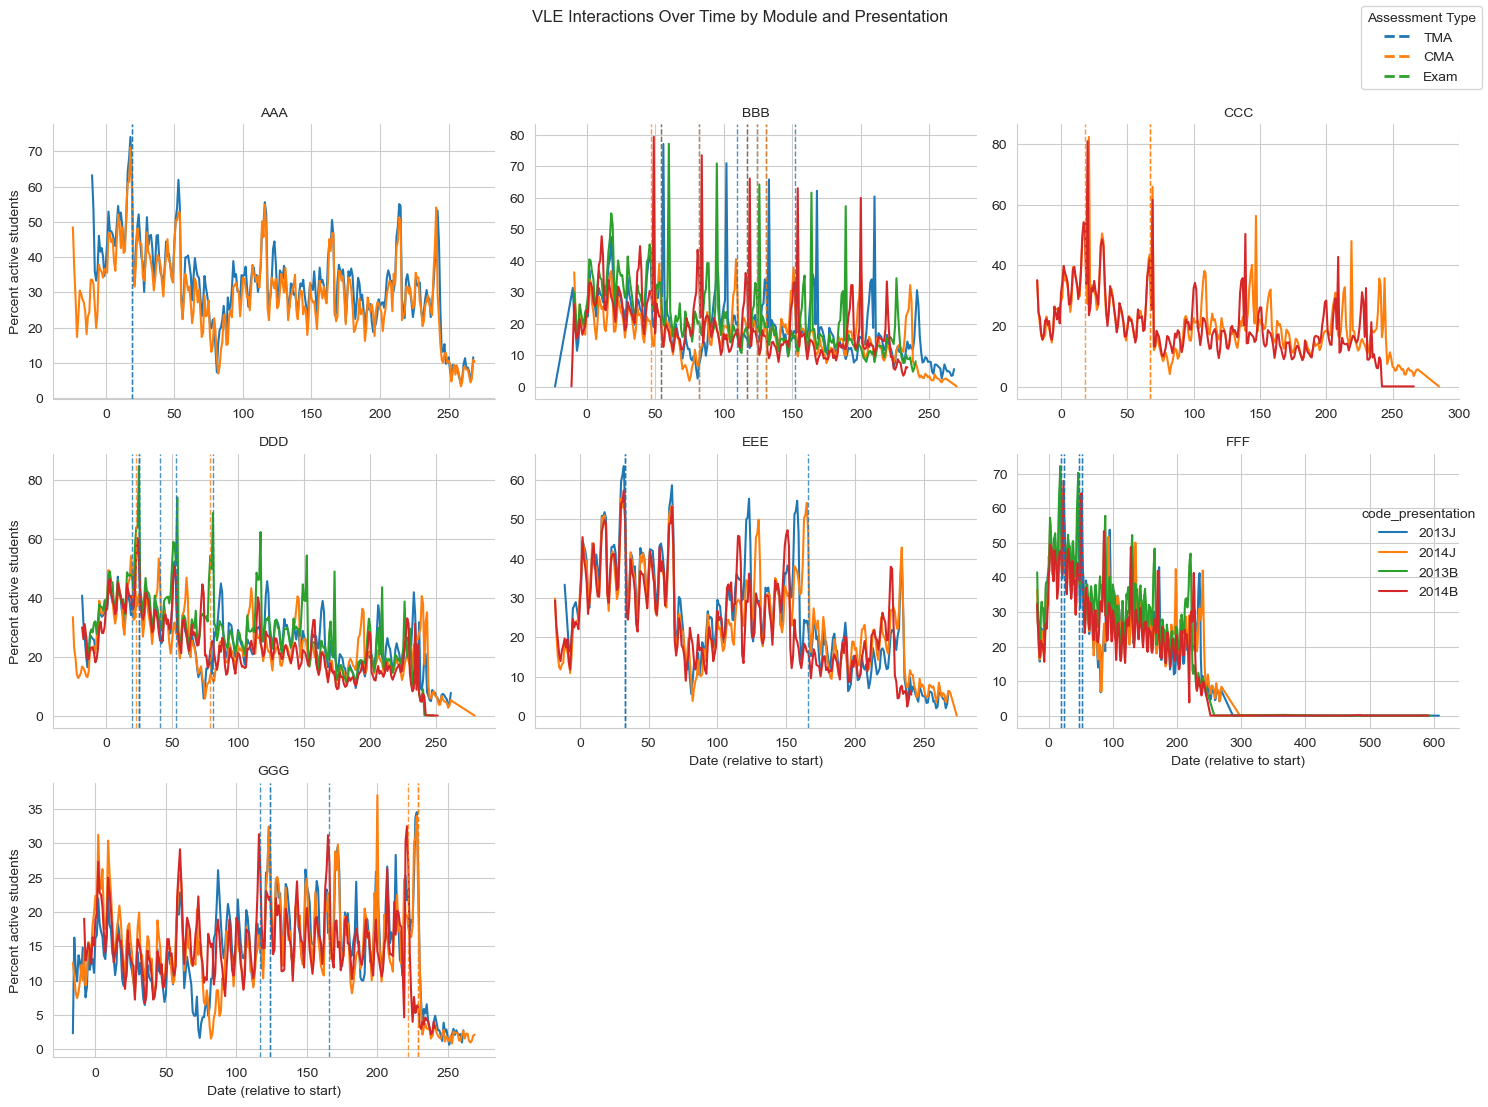

In [ ]:
# Base plot
g = sns.relplot(
    data=daily_avg_vle,
    x="date",
    y="percent_active_students",
    hue="code_presentation",
    kind="line",
    col="code_module",
    col_wrap=3,
    height=3.5,
    aspect=1.3,
    facet_kws={"sharey": False, "sharex": False}
)

type_colors = {
    "TMA": "tab:blue",
    "CMA": "tab:orange",
    "Exam": "tab:green"
}

near_due_unique = near_due[
    ["code_module", "code_presentation", "assessment_type", "due_date"]
].drop_duplicates()

# Overlay due dates with colors by assessment type
for (code_module, ax) in g.axes_dict.items():
    subset_due = near_due_unique[near_due_unique["code_module"] == code_module]
    for _, row in subset_due.iterrows():
        ax.axvline(
            x=row["due_date"],
            color=type_colors.get(row["assessment_type"], "gray"),  # fallback color
            linestyle="--",
            linewidth=1.0,
            alpha=0.8
        )

# Titles and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Date (relative to start)", "Percent active students")
g.fig.suptitle("VLE Interactions Over Time by Module and Presentation", y=1.05)

# Add a legend manually
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=c, lw=2, ls="--", label=atype)
           for atype, c in type_colors.items()]
g.fig.legend(handles=handles, title="Assessment Type", loc="upper right")


plt.tight_layout()
plt.show()

# Some of the peaks (top 5 were identified for each module-presentation) are associated with assessments. But others are not. 

Investigate why FFF shows data out to 600 days

In [84]:
daily_total_vle = daily_total_vle.merge(df_course_students, on=["code_module", "code_presentation"], how="left")

In [85]:
daily_total_vle_after_end = daily_total_vle[daily_total_vle["date"] > daily_total_vle["module_presentation_length"]]

print(daily_total_vle_after_end[daily_total_vle_after_end["total_vle"]>0])

Empty DataFrame
Columns: [code_module, code_presentation, date, total_vle, module_presentation_length, num_unique_students, num_unique_students_firsttime]
Index: []


In [78]:
daily_total_vle.groupby(["code_module","code_presentation"])["date"].max()

code_module  code_presentation
AAA          2013J                268.0
             2014J                269.0
BBB          2013B                240.0
             2013J                268.0
             2014B                234.0
             2014J                270.0
CCC          2014B                266.0
             2014J                285.0
DDD          2013B                248.0
             2013J                261.0
             2014B                251.0
             2014J                279.0
EEE          2013J                268.0
             2014B                241.0
             2014J                274.0
FFF          2013B                594.0
             2013J                608.0
             2014B                591.0
             2014J                325.0
GGG          2013J                261.0
             2014B                241.0
             2014J                269.0
Name: date, dtype: float64

In [86]:
assessments_after_end = df_meta_assessments[df_meta_assessments["date"] > df_meta_assessments["module_presentation_length"]]
assessments_after_end

,id_student,code_module,code_presentation,date,id_assessment,is_banked,score,assessment_type,due_date,weight,module_presentation_length,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration
14710,53709,FFF,2013B,483.0,34867.0,0.0,76.0,CMA,222.0,0.0,240,M,Wales,A Level or Equivalent,30-40%,0-35,0,60,N,Withdrawn,-67.0,159.0
27488,77998,FFF,2013B,578.0,34865.0,0.0,86.0,CMA,222.0,0.0,240,M,Ireland,Lower Than A Level,NaN,35-55,1,180,N,Withdrawn,-11.0,220.0
27489,77998,FFF,2013B,578.0,34867.0,0.0,80.0,CMA,222.0,0.0,240,M,Ireland,Lower Than A Level,NaN,35-55,1,180,N,Withdrawn,-11.0,220.0
27490,77998,FFF,2013B,584.0,34866.0,0.0,93.0,CMA,222.0,0.0,240,M,Ireland,Lower Than A Level,NaN,35-55,1,180,N,Withdrawn,-11.0,220.0
29501,81351,DDD,2013B,248.0,25340.0,0.0,0.0,Exam,240.0,100.0,240,M,Scotland,HE Qualification,90-100%,35-55,1,60,Y,Fail,-12.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1773960,2341830,DDD,2014J,279.0,25368.0,0.0,49.0,Exam,NaN,100.0,262,F,Scotland,HE Qualification,20-30%,0-35,1,90,N,Pass,-151.0,NaN
1805233,2480886,FFF,2014B,300.0,34891.0,0.0,93.0,CMA,227.0,0.0,241,F,East Anglian Region,A Level or Equivalent,80-90%,0-35,0,60,Y,Withdrawn,-39.0,101.0
1863654,2667478,FFF,2014B,252.0,34891.0,0.0,96.0,CMA,227.0,0.0,241,M,North Western Region,Lower Than A Level,80-90%,35-55,0,60,N,Withdrawn,-34.0,206.0
1868076,2683857,FFF,2013J,409.0,34878.0,0.0,87.0,CMA,236.0,0.0,268,M,South West Region,Lower Than A Level,70-80%,35-55,0,60,N,Withdrawn,-88.0,93.0


In [ ]:
summary = assessments_after_end.groupby(
    [ "code_module", "code_presentation","module_presentation_length","id_assessment", "assessment_type"]
).agg(
    num_unique_students=("id_student", "nunique"),
    min_date=("date", "min"),
    max_date=("date", "max")
).reset_index()

summary

# Several assessments were submitted after the end of the course and explains why there are data in the figures above as far out as 600 days 

,code_module,code_presentation,module_presentation_length,id_assessment,assessment_type,num_unique_students,min_date,max_date
0,BBB,2014J,262,15022.0,TMA,1,270.0,270.0
1,CCC,2014B,241,24290.0,Exam,3,242.0,266.0
2,CCC,2014J,269,24299.0,Exam,1,285.0,285.0
3,DDD,2013B,240,25340.0,Exam,4,241.0,248.0
4,DDD,2014B,241,25361.0,Exam,3,242.0,251.0
5,DDD,2014J,262,25368.0,Exam,1,279.0,279.0
6,EEE,2014J,269,30722.0,TMA,1,274.0,274.0
7,FFF,2013B,240,34863.0,TMA,1,258.0,258.0
8,FFF,2013B,240,34865.0,CMA,11,367.0,594.0
9,FFF,2013B,240,34866.0,CMA,7,367.0,592.0
